## Week 2 Assignment — Getting Started with PyTorch

## Pytorch Setup

Run the cell below first to confirm PyTorch is working. If it prints a version number, you're ready to go.


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
GPU available: False


---
### Part A — Warm-Up Concepts

Answer in your own words, **2–3 sentences each**. No code needed here — this just checks the reading made sense. Double-click each answer cell to edit it.


**A1.** What is a **tensor**, and how is it different from a normal Python list? Give one everyday example of data that could be stored as a tensor.

Ans.=Tensor is a data structure used in machine learning to store numbers in multiple dimensionsa and to perform fast mathematical operations on them effectively.Tensors are different from python lists as they can run on GPUs and enable fast and advanced computations.An everyday exmple of data that can be stored as a tensor is an image which can be stored as a 3D tensor(height*width*colour channels)



**A2.** What do the terms **shape**, **ndim** (dimensions), and **dtype** tell you about a tensor?

_Your answer:Shape tells the size of a tensor along each axis (e.g., a tensor with shape (3, 4) has 3 rows and 4 columns). ndim tells the number of dimensions or axes the tensor has, while dtype tells the type of data stored in the tensor, such as integers (int32) or decimals (float32)



**A3.** Why do we sometimes move tensors and models to a **GPU**? What problem does it solve?

_Your answer:_
We move tensors to GPUs as GPUs can perform many advanced computations simultaneously making training and inference much faster than on a CPU.This solves the problem of slow computation ,especially when working with large datasets and complex neural networks.


**A4.** In machine learning, what is the difference between **training data** and **test data**, and why must we keep them separate?

_Your answer:_Training data is used to teach the model by adjusting its parameters, while test data is used to evaluate how well the trained model performs on unseen examples. Keeping them separate ensures a fair assessment and helps detect whether the model is simply memorizing the training data instead of learning general patterns.



**A5.** In your own words, what is a model actually *"learning"* when we train it? (Hint: think about weights and bias.)

_Your answer:_
When we train a model, it learns the best values of its weights and biases so that its predictions are as close as possible to the correct answers. In other words, it learns the mathematical relationship or pattern between the input data and the output


---
### Part B — Tensor Basics

Write code for each task in the cell below it. **Print the result of every step** so we can see the output.


**B1.** Create a tensor of the numbers 1 to 10. Print its **shape**, **number of dimensions**, and **dtype**.

In [ ]:
# TODO: create the tensor and print shape, ndim, and dtype
tensor=torch.arange(1,11)
tensor.shape,tensor.ndim,tensor.dtype

(torch.Size([10]), 1, torch.int64)

**B2.** Create a random tensor of shape **(3, 4)**. Then create another of shape **(4, 2)** and perform a **matrix multiplication** between them. Print the shape of the result.

In [ ]:
# TODO: create two tensors and matrix-multiply them
tensor1=torch.rand(3,4)
tensor2=torch.rand(4,2)
tensor1@tensor2,torch.matmul(tensor1,tensor2)

(tensor([[0.6046, 0.8962],
         [0.6351, 1.1412],
         [0.6624, 1.0650]]),
 tensor([[0.6046, 0.8962],
         [0.6351, 1.1412],
         [0.6624, 1.0650]]))

**B3.** Take your random (3, 4) tensor and find its **minimum, maximum, mean, and sum**.

In [ ]:
# TODO: min / max / mean / sum
tensor1.max(),tensor1.min(),tensor1.sum(),tensor1.mean()

(tensor(0.9408), tensor(0.1332), tensor(7.5631), tensor(0.6303))

**B4.** Create a tensor with values from **0 to 100 in steps of 10**, then **reshape** it into shape **(2, 5)**.

In [ ]:
# TODO: create with torch.arange, then reshape
tensor=torch.arange(0,100,10)
tensor,tensor.reshape(2,5)

(tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]),
 tensor([[ 0, 10, 20, 30, 40],
         [50, 60, 70, 80, 90]]))

**B5.** Set the random **seed to 42**, create a random **(2, 3)** tensor, then explain in one line (in the markdown cell after) why setting a seed is useful.

In [ ]:
# TODO: set seed, then create the tensor
torch.manual_seed(42)
tensor1=torch.rand(2,3)
tensor1

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])

**B5 explanation:** _Why is setting a random seed useful?_

Setting a random seed makes random operations produce the same results every time the code is run.It is useful as I can access the result of the random function again just by using the seed once again.So I will not lose the result

---
### Part C — Mini-Project: Your First Model

This is the main event. You'll build a tiny model that learns a **straight line** — the classic *"hello world"* of deep learning. Follow the workflow from **Section 01** step by step.

### The goal
We'll invent some data that follows the rule **y = 0.7 × x + 0.3**. Your model doesn't know those numbers — its job is to **learn them from the data alone**. Run the cell below to create the data.


In [ ]:
import torch

# The "true" values our model will try to discover
weight, bias = 0.7, 0.3

# Create the data
X = torch.arange(0, 1, 0.02).unsqueeze(1)   # inputs,  shape: (50, 1)
y = weight * X + bias                        # outputs, shape: (50, 1)

print("X shape:", X.shape, "| y shape:", y.shape)
print("First 5 X values:", X[:5].squeeze())
print("First 5 y values:", y[:5].squeeze())

X shape: torch.Size([50, 1]) | y shape: torch.Size([50, 1])
First 5 X values: tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800])
First 5 y values: tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560])


### Your tasks

**C1.** Split the data into a **training set (first 80%)** and a **test set (last 20%)**. Print how many samples are in each.

In [ ]:
# TODO: split X and y into X_train, y_train, X_test, y_test
# Hint: 80% of 50 samples = 40
X_train, y_train=X[:40], y[:40]
X_test, y_test=X[40:],y[40:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

**C2.** Build a simple **model** using `torch.nn.Module` (or `nn.Linear`) that takes one input and produces one output.

In [ ]:
from torch import nn
# TODO: define your model class (or use nn.Linear(1, 1))
model=nn.Linear(1,1)
input=torch.tensor([[10]]).type(torch.float32)
output=model(input)
output

tensor([[-4.2813]], grad_fn=<AddmmBackward0>)

**C3.** Pick a **loss function** (try `nn.L1Loss`) and an **optimizer** (try `torch.optim.SGD` with a small learning rate like 0.01).

In [ ]:
# TODO: create the model instance, loss_fn, and optimizer
from torch import optim
lossfunction=nn.L1Loss()
optimizer=optim.SGD(params=model.parameters(),lr=0.01)

**C4.** Write a **training loop** for about **200 epochs**. In each loop: make predictions, calculate the loss, zero the gradients, backpropagate, and step the optimizer. **Print the epoch and loss every 20 epochs.**

In [ ]:
for epoch in range(200):
  model.train()
  y_preds=model(X_train)
  loss=lossfunction(y_preds,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model.eval()
  if epoch%20==0:
      print(epoch,f"loss={loss}")




0 loss=0.018815549090504646
20 loss=0.011942785233259201
40 loss=0.005073120351880789
60 loss=0.004824535455554724
80 loss=0.004824535455554724
100 loss=0.004824535455554724
120 loss=0.004824535455554724
140 loss=0.004824535455554724
160 loss=0.004824535455554724
180 loss=0.004824535455554724


**C5.** After training, print the model's **learned weight and bias**. How close are they to **0.7** and **0.3**?

In [ ]:
# TODO: print the learned parameters
# Hint: list(model.parameters()) or model.state_dict()
model.state_dict()

OrderedDict([('weight', tensor([[0.6901]])), ('bias', tensor([0.2990]))])

**C6.** Make **predictions on the test set**, and (optional nicety) **plot** the predictions against the actual values with matplotlib.

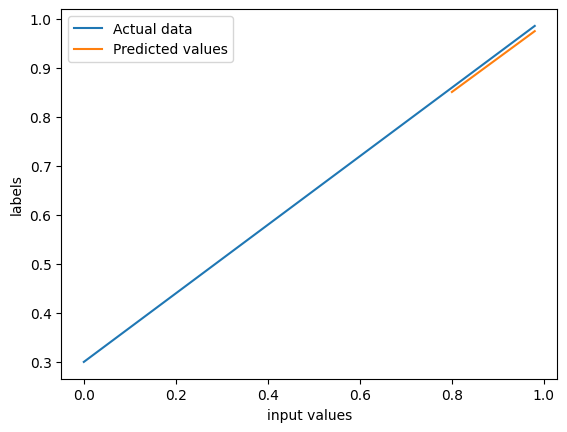

In [ ]:
import matplotlib.pyplot as plt
# TODO: predict on X_test (use torch.inference_mode()) and plot
model.eval()
with torch.inference_mode():
    test_preds=model(X_test)
line1=plt.plot(X,y)
line2=plt.plot(X_test,test_preds)
plt.legend(["Actual data","Predicted values"])
plt.xlabel("input values")
plt.ylabel("labels")
plt.show()


### ✅ What success looks like
- Your **loss value gets smaller** as training goes on.
- Your **learned weight and bias** end up close to **0.7** and **0.3**.
- You can explain, in a sentence, what your training loop is doing.
Ans=A training loop in PyTorch repeatedly makes predictions, calculates the error (loss), computes gradients using backpropagation, and updates the model's parameters to gradually improve its predictions.


---
### Part D — Reflection

A few honest sentences — this helps us help you next week.


**D1.** What was the single **most confusing** thing this week, and how did you (try to) figure it out?

_Your answer:_
The most confusing thing for me this week was understanding how linear regression works in PyTorch, especially how tensors, model parameters (weights and bias), and the training loop fit together. I tried to figure it out by experimenting with small code examples, checking tensor shapes at each step, and reviewing how the model updates its weights using the loss function and optimizer.




**D2.** Which of the five training-loop steps (predict → loss → zero gradients → backprop → step) still feels **fuzzy**?

_Your answer:_
The **backpropagation** step still feels a bit fuzzy to me. I understand that it calculates gradients for the model's weights and biases based on the loss, but I am still working on understanding exactly how these gradients are computed and propagated through the network.



**D3.** On a scale of **1–5**, how comfortable do you feel with tensors now? One line on why.

_Your answer:_
**4/5** — I am fairly comfortable with tensors now because I understand their basic properties such as shape, dimensions, and data types, and I can use them in simple PyTorch operations, though I still need more practice with advanced applications.



---
## ⭐ Bonus (Optional)

Only if you finished the rest and want a challenge:

- Change the learning rate to a **much larger** value (e.g. `1.0`) and a **much smaller** one (e.g. `0.0001`). What happens to the loss in each case? Write 2–3 sentences on what you observed.
- Peek at **Section 02 (Neural Network Classification)** and write down **one new idea** you noticed that wasn't in this week's work.


In [ ]:
# (Optional) Bonus experiments here

**Bonus notes:** _What did you observe?_
**Learning Rate Experiment:**
When I set the learning rate to **1.0**, the loss behaved strangely and did not decrease properly because the model was making updates that were too big. When I set it to **0.0001**, the loss decreased very slowly since the model was taking very small steps while learning.

**One New Idea from Section 02 (Neural Network Classification):**
One thing I learned was that classification models use functions like **sigmoid** to turn outputs into probabilities. This helps the model decide which class a particular input is most likely to belong to.

